# Module 2 · How much data is *really* here?

Before we test whether partner B beats partner A in Bing, one gate: **how much independent data is
in that slice?** Our rows are *click-outs*, and one visit can produce several click-outs. Rows that
share a visit are **not independent** — so the nominal `n` overstates the information, and a naive
test will fire too often.

**4-beat loop:** by hand → extract (`ni_core`) → wrap (`/profile-data`, `/significance-check --cluster`)
→ validate (an A/A simulation).

## By hand — click-outs share visits

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path as _Path
for _c in [_Path.cwd(), *_Path.cwd().parents]:          # portable: find the repo root
    if (_c / '.claude' / 'skills' / '_lib' / 'ni_core.py').exists():
        sys.path.insert(0, str(_c / '.claude' / 'skills' / '_lib')); break
import ni_core as C

clk = C.load_clickouts()
cl = clk[clk["clicked"]].copy()
sizes = cl.groupby("visit_iid").size()
print(f"click-out rows = {len(cl):,}   unique visits = {sizes.size:,}")
print(f"mean click-outs / visit = {sizes.mean():.3f}   max = {sizes.max()}")
print(f"visits with exactly 1 click-out = {(sizes==1).mean()*100:.1f}%")
assert sizes.size > 50_000 and sizes.max() >= 3

click-out rows = 94,998   unique visits = 70,126
mean click-outs / visit = 1.355   max = 5
visits with exactly 1 click-out = 73.3%


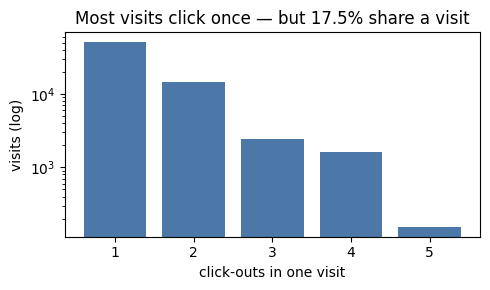

In [2]:
counts = sizes.value_counts().sort_index()
plt.figure(figsize=(5,3))
plt.bar(counts.index, counts.values, color="#4C78A8")
plt.yscale("log"); plt.xlabel("click-outs in one visit"); plt.ylabel("visits (log)")
plt.title("Most visits click once — but 17.5% share a visit")
plt.tight_layout(); plt.show()

## By hand — the design effect

Rows within a visit are correlated (they share the visit's conversion propensity). The **intraclass
correlation (ICC)** measures that; the **design effect** turns it into an effective-n:

$$\text{deff}=1+(\bar m-1)\,\text{ICC},\qquad n_\text{eff}=n/\text{deff}$$

where $\bar m$ is the mean cluster size. We compute ICC from one-way ANOVA components.

In [3]:
v = cl["revenue"].to_numpy(float)
cid = cl["visit_iid"].to_numpy()
ridx, uniq = pd.factorize(cid)
k = len(uniq); n = len(v)
grand = v.mean()
sum_i = np.bincount(ridx, weights=v); n_i = np.bincount(ridx).astype(float)
mean_i = sum_i / n_i
ms_between = (n_i * (mean_i - grand)**2).sum() / (k - 1)
ss_within = ((v - mean_i[ridx])**2).sum()
ms_within = ss_within / (n - k)
n0 = (n - (n_i**2).sum()/n) / (k - 1)
icc = (ms_between - ms_within) / (ms_between + (n0 - 1)*ms_within)
mbar = n / k
deff = 1 + (mbar - 1)*icc
print(f"ICC = {icc:.3f}   mean cluster size = {mbar:.3f}")
print(f"design effect deff = {deff:.3f}   effective n = {n/deff:,.0f}  ({n/deff/n*100:.0f}% of {n:,})")

ICC = 0.353   mean cluster size = 1.355
design effect deff = 1.125   effective n = 84,427  (89% of 94,998)


## Extract — the same thing, from the deterministic engine

In [4]:
de = C.design_effect(v, cid)
print({kk: (round(vv,3) if isinstance(vv,float) else vv) for kk,vv in de.items()})
assert np.isclose(de["icc"], icc) and np.isclose(de["deff"], deff)
# the drill-down slice is smaller but the same idea:
bing = cl[cl.channel=="Bing"]
deb = C.design_effect(bing.revenue.to_numpy(float), bing.visit_iid.to_numpy())
print(f"Bing slice: n={deb['n']:,}  deff={deb['deff']:.3f}  effective n≈{deb['n_eff']:,.0f}")

{'n': 94998, 'k': 70126, 'mbar': 1.355, 'icc': 0.353, 'deff': 1.125, 'n_eff': 84427.214}
Bing slice: n=20,436  deff=1.192  effective n≈17,147


## Validate — an A/A simulation (the money cell)

Here's the subtle part: because most visits click **once**, our click-grain deff is only ~1.11 — so
on *this* data the violation is real but **mild** (effective n ≈ 90% of nominal). The danger is that
the *same mechanism* bites hard the moment clusters get bigger — e.g. clustering the same **user**
across visits (which NI has, but this mock collapses to the visit).

To see it unambiguously, simulate a **null** (no real difference) with tunable clustering and watch
the naive row-level test over-fire while the cluster-correct test stays at 5%.

In [5]:
rng = np.random.default_rng(42)

def welch_reject(vals, mask, axis_n):
    c1 = mask.sum(1); c0 = axis_n - c1
    s1 = (mask*vals).sum(1); s0 = vals.sum(1) - s1
    m1, m0 = s1/c1, s0/c0
    sq1 = (mask*vals**2).sum(1); sq0 = (vals**2).sum(1) - sq1
    v1 = (sq1 - c1*m1**2)/(c1-1); v0 = (sq0 - c0*m0**2)/(c0-1)
    return np.abs((m1-m0)/np.sqrt(v1/c1 + v0/c0)) > 1.96

def aa_fpr(icc, m, G=200, R=1500):
    tau, sig = np.sqrt(icc), np.sqrt(1-icc)
    x = rng.normal(0, tau, (R, G))[:, :, None] + rng.normal(0, sig, (R, G, m))  # clustered null
    grp = (rng.random((R, G)) < 0.5)                     # assign whole clusters to A/B
    cluster = welch_reject(x.mean(2), grp, G).mean()     # 1 value per cluster (calibrated)
    naive = welch_reject(x.reshape(R, G*m), np.repeat(grp, m, 1), G*m).mean()  # rows as independent
    return naive, cluster

naive, cluster = aa_fpr(icc=0.5, m=5)                     # deff = 1+(5-1)*0.5 = 3
print("clustered null · ICC=0.5 · 5 rows/cluster (deff=3):")
print(f"  NAIVE row-level  false-positive rate = {naive*100:4.1f}%   ← should be 5%")
print(f"  CLUSTER-correct  false-positive rate = {cluster*100:4.1f}%")
assert naive > 0.15 and cluster < 0.09

clustered null · ICC=0.5 · 5 rows/cluster (deff=3):
  NAIVE row-level  false-positive rate = 26.0%   ← should be 5%
  CLUSTER-correct  false-positive rate =  6.1%


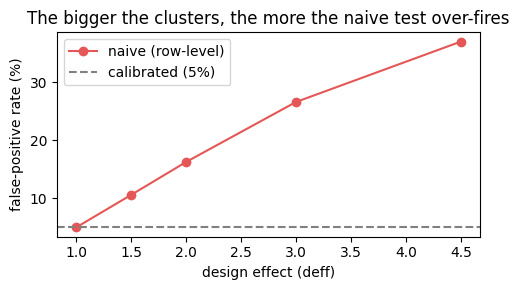

Our real click data sits near deff≈1.13 (mild) — but grows with coarser clustering.


In [6]:
ms = [1, 2, 3, 5, 8]
fprs = [aa_fpr(0.5, m)[0]*100 for m in ms]
deffs = [1 + (m-1)*0.5 for m in ms]
plt.figure(figsize=(5,3))
plt.plot(deffs, fprs, "o-", color="#E45756", label="naive (row-level)")
plt.axhline(5, ls="--", c="grey", label="calibrated (5%)")
plt.xlabel("design effect (deff)"); plt.ylabel("false-positive rate (%)")
plt.title("The bigger the clusters, the more the naive test over-fires")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Our real click data sits near deff≈{de['deff']:.2f} (mild) — but grows with coarser clustering.")

## Close

The naive test rejects far more than 5% of the time — it manufactures "significant" differences out
of thin air, because it counts correlated rows as independent evidence. The fix is the **effective
n** and a **cluster bootstrap** (resample visits, not rows).

**→ Automated by:** `/profile-data` (prints the effective-n line) and `/significance-check --cluster`.
**Gate:** at click grain, always treat `n` as the *effective* n and cluster on `visit_iid`.
**Next: Module 3 — is the difference real?**